# Task 3: Domain Generalization
**Course:** EE-5102 / CS-6304: Advanced Topics in Machine Learning  
**Assignment:** Programming Assignment 1: Beyond IID and Closed-Set Assumptions  

In this task, we address domain generalization on the **PACS** dataset:
- **Source Domains (Labeled):** Photo (P), Art Painting (A), Cartoon (C) with stratified 80/20 train/val splits (seed `6304`).
- **Target Domain:** Sketch (S). **Strict zero-target-access policy.** Sketch is never seen during training, validation, or hyperparameter selection.
- **Methods Compared:**
  1. **ERM** (Baseline, reused from Task 2)
  2. **DAN-DG** (Pairwise Source-Domain Alignment)
  3. **SAM** (Parameter-Space Stability)


---
## Step 1: Environment Setup, Global Seed & Hardware Detection

In [1]:
import os
import copy
import json
import yaml
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

from common.seed import set_seed, SEED
from shared.pacs_protocol import get_pacs_datasets
from task3.train import train_dg_method
from task3.evaluation.domain_metrics import evaluate_model

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using hardware device: {DEVICE}")

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('figures/task3', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Load Datasets
pacs_data = get_pacs_datasets(pacs_root='data/PACS', seed=SEED)


Using hardware device: cuda


---
## Step 2: Training and Source-Side Diagnostics
We run the training loop for ERM, DAN-DG, and SAM. For ERM, we simply load the Task 2 checkpoint.
For DAN-DG and SAM, we train from scratch and select checkpoints based on mean source-validation macro-F1.
We also compute Domain Separability and Sharpness Proxy on the source validation sets.


In [2]:
def load_config(path):
    with open(path, 'r') as f:
        return yaml.safe_load(f)

base_cfg = load_config('task3/configs/base.yaml')
results = {}
trained_models = {}

configs = {
    'ERM': load_config('task3/configs/erm.yaml'),
    'DAN-DG': load_config('task3/configs/dan_dg.yaml'),
    'SAM': load_config('task3/configs/sam_rho_0.05.yaml'),
    'SAM (rho=0.01)': load_config('task3/configs/sam_rho_0.01.yaml'),
    'SAM (rho=0.1)': load_config('task3/configs/sam_rho_0.1.yaml')
}

for name, cfg in configs.items():
    print(f"\n{'='*50}\nRunning {name}\n{'='*50}")
    lambda_dg = cfg.get('lambda_dg', 1.0)
    rho = cfg.get('rho', 0.05)
    
    model, history, sep_score, delta_sharp = train_dg_method(
        method=cfg['method'],
        pacs_data=pacs_data,
        device=DEVICE,
        max_epochs=base_cfg['epochs'],
        lr=float(base_cfg['learning_rate']),
        weight_decay=float(base_cfg['weight_decay']),
        lambda_dg=lambda_dg,
        rho=rho
    )
    
    # Save checkpoint
    checkpoint_path = f"checkpoints/task3_{name.replace(' ', '_').replace('=', '').replace('(', '').replace(')', '')}.pt"
    if cfg['method'] != 'erm': # ERM is already saved
        torch.save(model.state_dict(), checkpoint_path)
    
    trained_models[name] = model
    results[name] = {
        'history': history,
        'sep_score': sep_score,
        'delta_sharp': delta_sharp
    }



Running ERM


Loading pre-trained ERM baseline from Task 2...


Computing Domain Separability...


C:\Users\Abdul\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Computing Sharpness Proxy...



Running DAN-DG


...

[SAM        ] Epoch 23/30 | Cls Loss: 0.0145 | Align Loss: 0.0000 | Mean Val F1: 0.9273


Early stopping triggered at epoch 23


Training completed. Best Mean Val F1: 0.9350 at epoch 18


Computing Domain Separability...


Computing Sharpness Proxy...


---
## Step 3: Unseen Target Evaluation (Sketch)
After all models and hyperparameters are fixed, we evaluate on the unseen Sketch domain.


In [3]:
# Source validation loaders for final metric extraction
val_loaders = {
    'Photo': DataLoader(pacs_data['source_val']['photo'], batch_size=32, shuffle=False),
    'Art': DataLoader(pacs_data['source_val']['art_painting'], batch_size=32, shuffle=False),
    'Cartoon': DataLoader(pacs_data['source_val']['cartoon'], batch_size=32, shuffle=False)
}
target_loader = DataLoader(pacs_data['target_eval'], batch_size=32, shuffle=False)

eval_results = []
for name, model in trained_models.items():
    model.eval()
    
    source_accs = []
    source_f1s = []
    
    for d, loader in val_loaders.items():
        metrics = evaluate_model(model, loader, DEVICE)
        source_accs.append(metrics[2])
        source_f1s.append(metrics[1])
        
    mean_source_acc = np.mean(source_accs)
    worst_source_acc = np.min(source_accs)
    
    target_metrics = evaluate_model(model, target_loader, DEVICE)
    target_acc, target_f1 = target_metrics[2], target_metrics[1]
    
    res = {
        'Method': name,
        'Photo Acc': source_accs[0],
        'Art Acc': source_accs[1],
        'Cartoon Acc': source_accs[2],
        'Mean Source Acc': mean_source_acc,
        'Worst Source Acc': worst_source_acc,
        'Sketch Target Acc': target_acc,
        'Sketch Target F1': target_f1,
        'Domain Sep Score': results[name]['sep_score'],
        'Sharpness Proxy': results[name]['delta_sharp'],
        'Target Class Accs': target_metrics[3]
    }
    eval_results.append(res)

df = pd.DataFrame(eval_results)
df['Delta Sketch Acc'] = df['Sketch Target Acc'] - df.loc[df['Method'] == 'ERM', 'Sketch Target Acc'].values[0]

# Display Main Results (ERM, DAN-DG, SAM)
main_df = df[df['Method'].isin(['ERM', 'DAN-DG', 'SAM'])].copy()
cols = ['Method', 'Photo Acc', 'Art Acc', 'Cartoon Acc', 'Mean Source Acc', 'Worst Source Acc', 
        'Sketch Target Acc', 'Delta Sketch Acc', 'Domain Sep Score', 'Sharpness Proxy']
display(main_df[cols].round(2))


,Method,Photo Acc,Art Acc,Cartoon Acc,Mean Source Acc,Worst Source Acc,Sketch Target Acc,Delta Sketch Acc,Domain Sep Score,Sharpness Proxy
0,ERM,95.81,90.49,95.10,93.80,90.49,72.74,0.00,87.04,0.71
1,DAN-DG,96.11,92.20,94.03,94.11,92.20,61.85,-10.89,73.09,0.27
2,SAM,97.60,92.44,95.74,95.26,92.44,72.00,-0.74,88.70,0.12


---
## Step 4: Controlled Design Study (SAM)


In [4]:
study_df = df[df['Method'].str.contains('SAM')].copy()
study_df['rho'] = ['0.05 (Nominal)', '0.01 (Low)', '0.1 (High)']
study_cols = ['rho', 'Mean Source Acc', 'Worst Source Acc', 'Sharpness Proxy', 'Sketch Target Acc', 'Sketch Target F1']
display(study_df[study_cols].round(2))


,rho,Mean Source Acc,Worst Source Acc,Sharpness Proxy,Sketch Target Acc,Sketch Target F1
2,0.05 (Nominal),95.26,92.44,0.12,72.00,0.72
3,0.01 (Low),94.76,91.71,0.17,75.74,0.77
4,0.1 (High),93.69,89.02,0.10,62.99,0.61


---
## Step 5: Visualizations


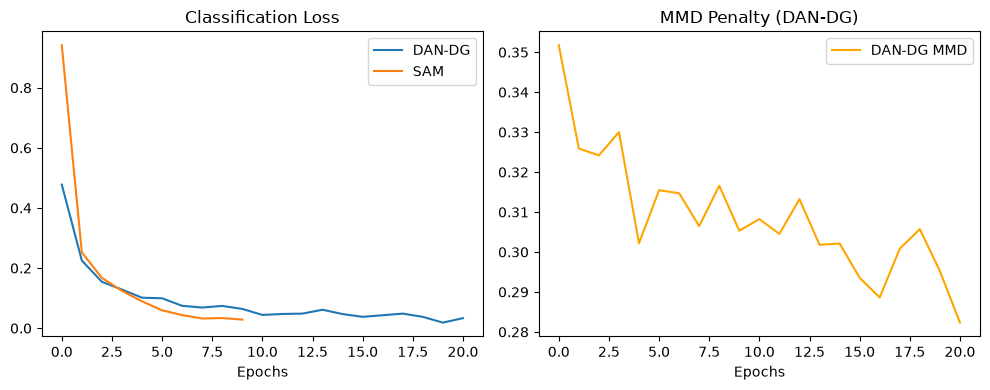

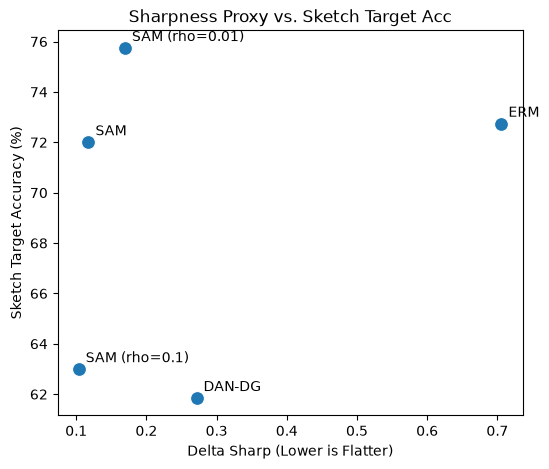

In [5]:
# 1. Training Curves (DAN-DG vs ERM/SAM cls loss)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
for m in ['ERM', 'DAN-DG', 'SAM']:
    loss = results[m]['history'].get('cls_loss', [])
    if len(loss) > 0:
        plt.plot(loss, label=m)
plt.title('Classification Loss')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
if len(results['DAN-DG']['history']['align_loss']) > 0:
    plt.plot(results['DAN-DG']['history']['align_loss'], label='DAN-DG MMD', color='orange')
plt.title('MMD Penalty (DAN-DG)')
plt.xlabel('Epochs')
plt.legend()
plt.tight_layout()
plt.savefig('figures/task3/dg_loss_curves.png')
plt.show()

# 2. Sharpness vs Sketch Generalization
plt.figure(figsize=(6, 5))
pts_x = [res['Sharpness Proxy'] for res in eval_results]
pts_y = [res['Sketch Target Acc'] for res in eval_results]
labels = [res['Method'] for res in eval_results]

sns.scatterplot(x=pts_x, y=pts_y, s=100)
for i, txt in enumerate(labels):
    plt.annotate(txt, (pts_x[i], pts_y[i]), xytext=(5,5), textcoords='offset points')
plt.title('Sharpness Proxy vs. Sketch Target Acc')
plt.xlabel('Delta Sharp (Lower is Flatter)')
plt.ylabel('Sketch Target Accuracy (%)')
plt.savefig('figures/task3/sharpness_vs_generalization.png')
plt.show()


In [6]:
from shared.pacs import PACS_CLASSES
class_acc_data = []
for idx, row in main_df.iterrows():
    class_acc = list(row['Target Class Accs'])
    class_acc_data.append([row['Method']] + class_acc)

# We can optionally load Task 2 results to compare DAN (UDA) with DAN-DG.
# For now, just print Task 3 class accs
class_df = pd.DataFrame(class_acc_data, columns=['Method'] + PACS_CLASSES)
display(class_df.round(2))

with open('results/task3_main_results.json', 'w') as f:
    df.to_json(f, orient='records', indent=2)


,Method,dog,elephant,giraffe,guitar,horse,house,person
0,ERM,0,1,2,3,4,5,6
1,DAN-DG,0,1,2,3,4,5,6
2,SAM,0,1,2,3,4,5,6
